# Evaluation of results

For the assessment of the optimization result, several result output functions are available. They can be categorized into output in form of tables, geo-referenced output visualization and the full time series visualization.


In [1]:
import fine.IOManagement.xarrayIO as xrIO
import fine as fn
import pandas as pd  # Used to manage data in tables
import shapely as shp  # Used to generate geometric objects
import numpy as np  # Used to generate random input data
import geopandas as gpd  # Used to display geo-referenced plots
from pathlib import Path
cwd = Path.cwd().resolve()
base_path = cwd.parents[2]

nc_file_optimized = base_path / "examples" / "Examples" / "NetCDF" / "optimized_esm.nc"
esM = xrIO.readNetCDFtoEnergySystemModel(nc_file_optimized)


## Create a regional shape file and visualize it

Information on the geometrical shape of the investigated regions can either be downloaded from a website (e.g. from https://gadm.org/) or manually created. In this notebook, the geometries are manually created.

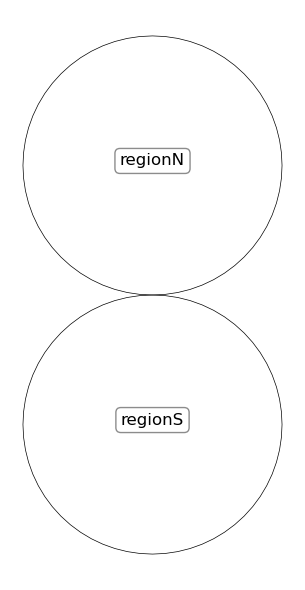

In [ ]:

regions_shp = base_path / "examples" / "Examples" / "_04_Evaluation_results" / "shape_files" /"regions.shp"
lines_shp = base_path / "examples" / "Examples" / "_04_Evaluation_results" / "shape_files" /"lines.shp"

# Create two circles, representing the two regions, and store their geometries in a shape file
shpRegionS = shp.geometry.Point(0.5, 0.5).buffer(0.5)
shpRegionN = shp.geometry.Point(0.5, 1.5).buffer(0.5)
regionsGdf = gpd.GeoDataFrame(
    {"geometry": [shpRegionN, shpRegionS], "regionName": ["regionN", "regionS"]},
    index=["regionN", "regionS"],
    crs="epsg:3035",
)
regionsGdf.to_file(regions_shp)

# Create a line, representing the connection between the two regions, and store its geometry in a
# shape file
lines = shp.geometry.LineString([(0.5, 0.5), (0.5, 1.5)])
linesGdf = gpd.GeoDataFrame(
    {
        "geometry": [lines, lines],
        "loc0": ["regionN", "regionS"],
        "loc1": ["regionS", "regionN"],
    },
    index=["regionN_regionS", "regionS_regionN"],
    crs="epsg:3035",
)
linesGdf.to_file(lines_shp)

# Visualize the geometric representation of the two regions
fig, ax = fn.plotLocations(regions_shp, indexColumn="regionName", plotLocNames=True)

## Display optimization summaries

For each modeling class, an optimization summary can be stored and displayed. 

In [3]:
srcSnkSummary = esM.getOptimizationSummary("SourceSinkModel", outputLevel=1)
display(esM.getOptimizationSummary("SourceSinkModel", outputLevel=2))

regionN  \
Component          Property         Unit                             
Wind turbines      NPVcontribution  [1e9 Euro]        37102.296187   
                   TAC              [1e9 Euro/a]      37102.296187   
                   capacity         [GW$_{el}$]         253.738364   
                   capexCap         [1e9 Euro/a]      31012.575444   
                   commissioning    [GW$_{el}$]         253.738364   
                   invest           [1e9 Euro]       304486.037190   
                   operation        [GW$_{el}$*h]    468593.977151   
                   operation_annual [GW$_{el}$*h/a]  468593.977151   
                   opexCap          [1e9 Euro/a]       6089.720744   
Electricity demand operation        [GW$_{el}$*h]    205291.430000   
                   operation_annual [GW$_{el}$*h/a]  205291.430000   

                                                           regionS  
Component          Property         Unit                            
Wind turbines      NPVcontribution  [1e9 Euro]         8042.497364  
                   TAC              [1e9 Euro/a]       8042.497364  
                   capacity         [GW$_{el}$]          55.001721  
                   capexCap         [1e9 Euro/a]       6722.456071  
                   commissioning    [GW$_{el}$]          55.001721  
                   invest           [1e9 Euro]        66002.064648  
                   operation        [GW$_{el}$*h]     87792.121410  
                   operation_annual [GW$_{el}$*h/a]   87792.121410  
                   opexCap          [1e9 Euro/a]       1320.041293  
Electricity demand operation        [GW$_{el}$*h]    328475.750000  
                   operation_annual [GW$_{el}$*h/a]  328475.750000

In [4]:
convSummary = esM.getOptimizationSummary("ConversionModel", outputLevel=1)
display(esM.getOptimizationSummary("ConversionModel", outputLevel=2))

,,,regionN,regionS
Component,Property,Unit,,


In [5]:
storSummary = esM.getOptimizationSummary("StorageModel", outputLevel=1)
display(esM.getOptimizationSummary("StorageModel", outputLevel=2))

regionN  \
Component        Property                  Unit                            
Li-ion batteries NPVcontribution           [1e9 Euro]          37.512395   
                 TAC                       [1e9 Euro/a]        37.512395   
                 capacity                  [GW$_{el}$*h]     2232.502962   
                 capexCap                  [1e9 Euro/a]        33.047389   
                 commissioning             [GW$_{el}$*h]     2232.502962   
                 invest                    [1e9 Euro]         337.107947   
                 operationCharge           [GW$_{el}$*h]    95263.216618   
                 operationCharge_annual    [GW$_{el}$*h/a]  95263.216618   
                 operationDischarge        [GW$_{el}$*h]    85637.088767   
                 operationDischarge_annual [GW$_{el}$*h/a]  85637.088767   
                 opexCap                   [1e9 Euro/a]         4.465006   

                                                                 regionS  
Component        Property                  Unit                           
Li-ion batteries NPVcontribution           [1e9 Euro]          13.695107  
                 TAC                       [1e9 Euro/a]        13.695107  
                 capacity                  [GW$_{el}$*h]      815.047056  
                 capexCap                  [1e9 Euro/a]        12.065013  
                 commissioning             [GW$_{el}$*h]      815.047056  
                 invest                    [1e9 Euro]         123.072105  
                 operationCharge           [GW$_{el}$*h]    27429.926101  
                 operationCharge_annual    [GW$_{el}$*h/a]  27429.926101  
                 operationDischarge        [GW$_{el}$*h]    24584.192163  
                 operationDischarge_annual [GW$_{el}$*h/a]  24584.192163  
                 opexCap                   [1e9 Euro/a]         1.630094

In [6]:
transSummary = esM.getOptimizationSummary("TransmissionModel", outputLevel=1)
display(esM.getOptimizationSummary("TransmissionModel", outputLevel=2))

regionN  \
Component    Property         Unit                locationIn            
AC cables    capacity         [GW$_{el}$]         regionN         NaN   
                                                  regionS        30.0   
             commissioning    [GW$_{el}$]         regionN         NaN   
                                                  regionS        30.0   
             operation        [GW$_{el}$*h]       regionN         NaN   
             operation_annual [GW$_{el}$*h/a]     regionN         NaN   
NG pipelines capacity         [GW$_{CH_{4},LHV}$] regionN         NaN   
                                                  regionS       100.0   
             commissioning    [GW$_{CH_{4},LHV}$] regionN         NaN   
                                                  regionS       100.0   

                                                                  regionS  
Component    Property         Unit                locationIn               
AC cables    capacity         [GW$_{el}$]         regionN         30.0000  
                                                  regionS             NaN  
             commissioning    [GW$_{el}$]         regionN         30.0000  
                                                  regionS             NaN  
             operation        [GW$_{el}$*h]       regionN     253676.4193  
             operation_annual [GW$_{el}$*h/a]     regionN     253676.4193  
NG pipelines capacity         [GW$_{CH_{4},LHV}$] regionN        100.0000  
                                                  regionS             NaN  
             commissioning    [GW$_{CH_{4},LHV}$] regionN        100.0000  
                                                  regionS             NaN

## Display regional and operational plots

Georeferenced plots as well as plots representing time series can be displayed for each component.

### Wind turbines

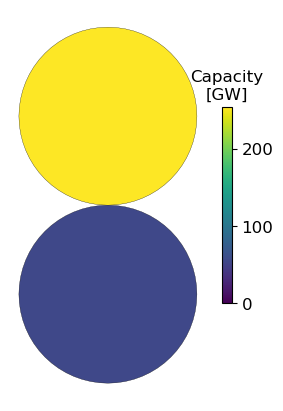

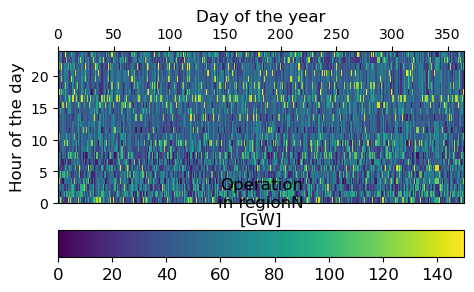

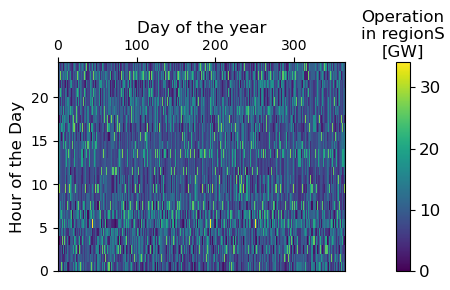

In [7]:
# If wind turbines are built, their capacities are displayed in a geo-referenced plot
if srcSnkSummary.loc[("Wind turbines", "capacity", "[GW$_{el}$]")].sum() > 0:
    fig, ax = fn.plotLocationalColorMap(
        esM,
        "Wind turbines",
        "regions.shp",
        "regionName",
        perArea=False,
        zlabel="Capacity\n[GW]\n",
        figsize=(4, 4),
    )
else:
    print("No wind turbines built.")

# If wind turbines are built in regionN, their operation is displayed as heatmap
if srcSnkSummary.loc[("Wind turbines", "capacity", "[GW$_{el}$]"), "regionN"] > 0:
    fig, ax = fn.plotOperationColorMap(
        esM,
        "Wind turbines",
        "regionN",
        figsize=(5, 3),
        xlabel="Day of the year",
        ylabel="Hour of the day",
        zlabel="Operation\nin regionN\n[GW]",
    )

# If wind turbines are built in regionS, their operation is displayed as heatmap
if srcSnkSummary.loc[("Wind turbines", "capacity", "[GW$_{el}$]"), "regionS"] > 0:
    fig, ax = fn.plotOperationColorMap(
        esM,
        "Wind turbines",
        "regionS",
        figsize=(5, 3),
        xlabel="Day of the year",
        ylabel="Hour of the Day",
        zlabel="Operation\nin regionS\n[GW]",
        orientation="vertical",
    )

### Gas power plants

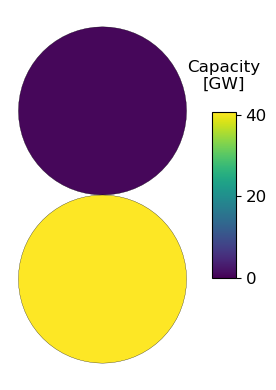

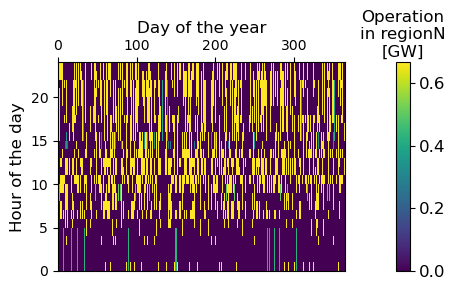

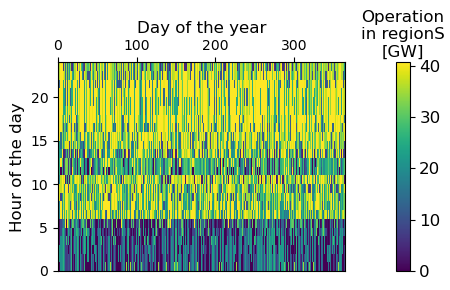

In [ ]:
# If CCGT plants are built, their capacities are displayed in a geo-referenced plot
if convSummary.loc[("Gas power plants", "capacity", "[GW$_{el}$]")].sum() > 0:
    fig, ax = fn.plotLocationalColorMap(
        esM,
        "Gas power plants",
        "regions.shp",
        "regionName",
        perArea=False,
        zlabel="Capacity\n[GW]\n",
        figsize=(4, 4),
    )
else:
    print("No CCGT plants built.")

# If CCGT plants are built in regionS, their operation is displayed as heatmap
if convSummary.loc[("Gas power plants", "capacity", "[GW$_{el}$]"), "regionN"] > 0:
    fig, ax = fn.plotOperationColorMap(
        esM,
        "Gas power plants",
        "regionN",
        figsize=(5, 3),
        xlabel="Day of the year",
        ylabel="Hour of the day",
        zlabel="Operation\nin regionN\n[GW]",
        orientation="vertical",
    )

# If CCGT plants are built in regionS, their operation is displayed as heatmap
if convSummary.loc[("Gas power plants", "capacity", "[GW$_{el}$]"), "regionS"] > 0:
    fig, ax = fn.plotOperationColorMap(
        esM,
        "Gas power plants",
        "regionS",
        figsize=(5, 3),
        xlabel="Day of the year",
        ylabel="Hour of the day",
        zlabel="Operation\nin regionS\n[GW]",
        orientation="vertical",
    )

### Batteries

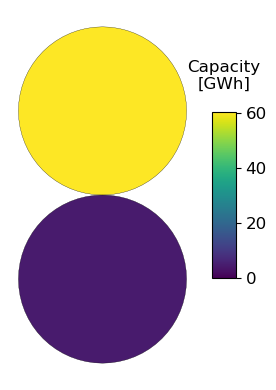

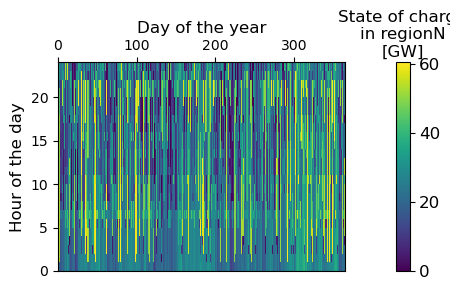

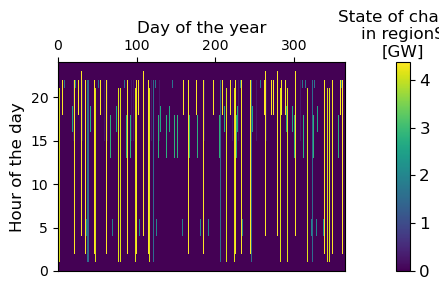

In [ ]:
# If batteries are built, their capacities are displayed in a geo-referenced plot
if storSummary.loc[("Batteries", "capacity", "[GW$_{el}$*h]")].sum() > 0:
    fig, ax = fn.plotLocationalColorMap(
        esM,
        "Batteries",
        "regions.shp",
        "regionName",
        perArea=False,
        zlabel="Capacity\n[GWh]\n",
        figsize=(4, 4),
    )
else:
    print("No batteries built.")

# If batteries are built in regionS, their storage inventory is displayed as heatmap
if storSummary.loc[("Batteries", "capacity", "[GW$_{el}$*h]"), "regionN"] > 0:
    fig, ax = fn.plotOperationColorMap(
        esM,
        "Batteries",
        "regionN",
        figsize=(5, 3),
        xlabel="Day of the year",
        ylabel="Hour of the day",
        zlabel="State of charge\nin regionN\n[GW]",
        variableName="stateOfChargeOperationVariablesOptimum",
        orientation="vertical",
    )

# If batteries are built in regionS, their storage inventory is displayed as heatmap
if storSummary.loc[("Batteries", "capacity", "[GW$_{el}$*h]"), "regionS"] > 0:
    fig, ax = fn.plotOperationColorMap(
        esM,
        "Batteries",
        "regionS",
        figsize=(5, 3),
        xlabel="Day of the year",
        ylabel="Hour of the day",
        zlabel="State of charge\nin regionS\n[GW]",
        variableName="stateOfChargeOperationVariablesOptimum",
        orientation="vertical",
    )

### AC cables

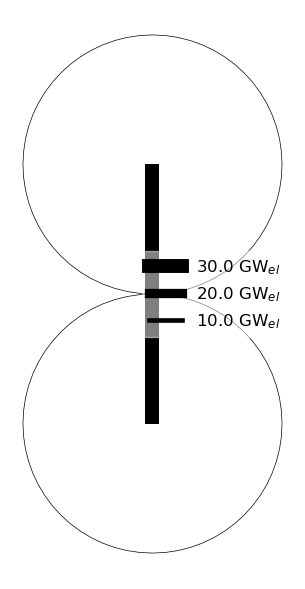

In [ ]:
# The built AC cable capacities are displayed
fig, ax = fn.plotLocations("regions.shp", indexColumn="regionName")
fig, ax = fn.plotTransmission(
    esM,
    "AC cables",
    "lines.shp",
    loc0="loc0",
    loc1="loc1",
    fig=fig,
    ax=ax,
    cbHeight=0.4,
)

### Electricity demand

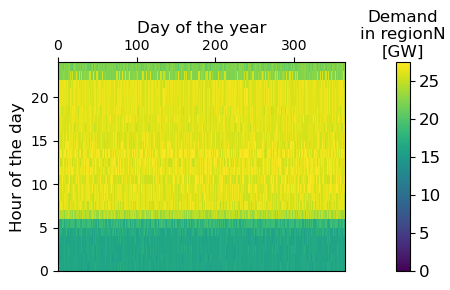

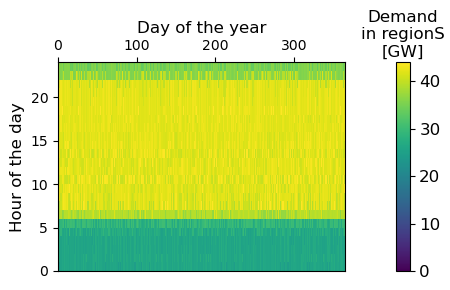

In [ ]:
# The electricity demand time series in regionN is displayed
fig, ax = fn.plotOperationColorMap(
    esM,
    "Electricity demand",
    "regionN",
    figsize=(5, 3),
    xlabel="Day of the year",
    ylabel="Hour of the day",
    zlabel="Demand\nin regionN\n[GW]",
    orientation="vertical",
)

# The electricity demand time series in regionS is displayed
fig, ax = fn.plotOperationColorMap(
    esM,
    "Electricity demand",
    "regionS",
    figsize=(5, 3),
    xlabel="Day of the year",
    ylabel="Hour of the day",
    zlabel="Demand\nin regionS\n[GW]",
    orientation="vertical",
)